In [1]:
config = {
    "reference": {
                "tag": "Apple",
           "filename": "../Apple data/0001_hr.csv",
         "start_time": "2024-10-11 13:27:48",
           "end_time": "2024-10-11 14:50:38",
        "time_format": "%Y-%m-%d %H:%M:%S",
             "window": "10T",
          "time_zone": 'US/Eastern'
    },
    "target": {
                "tag": "Pixel",
           "filename": "../Pixel/Heart_combined.csv",
         "start_time": 1728667685810,
           "end_time": 1728678611293,
        "time_format": "ms",
             "window": "10T",
          "time_zone": 'US/Eastern'
    },
    "output": {
           "filename": "../Pixel/Heart_realigned_1.csv"
    }
}

#print(config)

2024-10-11 13:28:05.810000-04:00 2024-10-11 16:30:11.293000-04:00 2024-10-11 13:11:15.454000-04:00


<Figure size 1200x600 with 0 Axes>

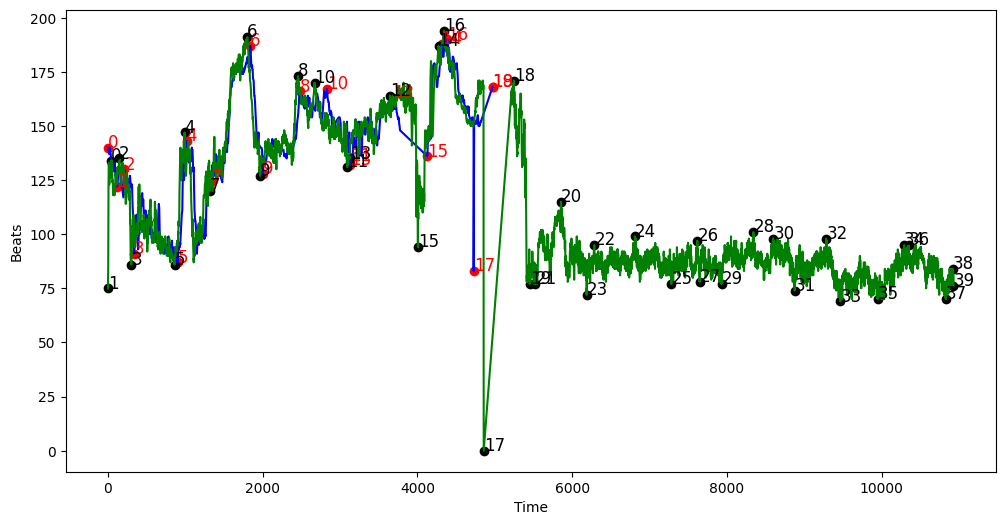

In [2]:
from aligner import DataSeries
import matplotlib.pyplot as plt

ds1 = DataSeries(config["reference"], line_color="blue", label_color="red")
ds1.load_apple_hr()

plt.figure(figsize=(12,6))
fig1, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

ds1.plot_relative(ax1)

ds2 = DataSeries(config["target"], line_color="green", label_color="black")
ds2.load_pixel_hr()

ds2.plot_relative(ax1)

plt.show()

Choose aligning points (e.g, 10,9):  6,6


6 6


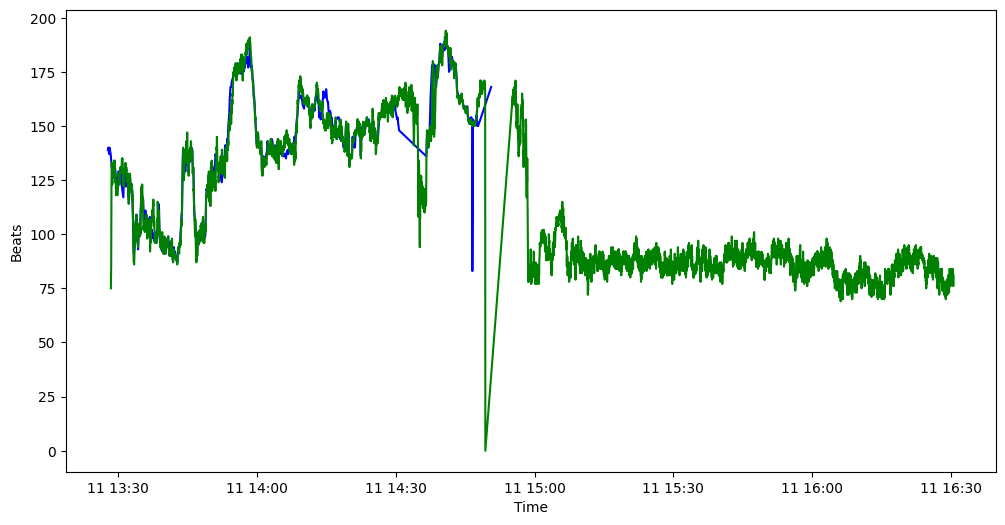

In [3]:
user_input = input("Choose aligning points (e.g, 10,9): ")
tokens = user_input.split(',')
    
point1 = int(tokens[0])
point2 = int(tokens[1])

ds1.align_point = point1
ds2.align_point = point2

print(point1, point2)

fig2, ax2 = plt.subplots(figsize=(12, 6), dpi=100)


ref_time = ds1.get_ref_time()
ds2.re_align(ref_time)

ds1.plot_absolute(ax2)
ds2.plot_absolute(ax2)


plt.show()


In [4]:
filename = config["output"]["filename"]
ds2.hr2csv(filename)
print("Successfully save file to %s" % filename)

Successfully save file to ../Pixel/Heart_realigned_1.csv
